### Sierraleone-bumbuna Solar Data: Profiling, Cleaning & EDA
##### **Objective 1**: Clean, explore, and gain insights from sierraleone-bumbuna solar dataset.

In [ ]:
# FORCE inline plotting
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10, 6)  # default size

In [18]:
import pandas as pd                           # DataFrames & CSV handling
import numpy as np                            # Numerical operations (arrays, math)
import matplotlib.pyplot as plt               # Base plotting library
import seaborn as sns                         # Statistical visualizations (heatmaps, etc.)
import warnings                               # Control warning messages
warnings.filterwarnings('ignore')

In [19]:
# Set style for better-looking plots
plt.style.use('seaborn-v0_8')                # Use seaborn style for matplotlib
sns.set_palette("husl")                      # Set a colorful palette for plots
get_ipython().run_line_magic('matplotlib', 'inline')  # Show plots inline in notebook

In [20]:
# Load the raw Benin dataset from the data folder
df = pd.read_csv('../data/sierraleone-bumbuna.csv')  # Read CSV into a DataFrame
print(f"Shape: {df.shape}")                  # Print number of rows and columns
df.head()                                    # Display first 5 rows to inspect structure

Shape: (525600, 19)


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-30 00:01,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.1,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
1,2021-10-30 00:02,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
2,2021-10-30 00:03,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.2,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN
3,2021-10-30 00:04,-0.7,0.0,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.1,22.3,22.6,NaN
4,2021-10-30 00:05,-0.7,-0.1,-0.8,0.0,0.0,21.9,99.3,0.0,0.0,0.0,0.0,0.0,1002,0,0.0,22.3,22.6,NaN


In [21]:
# In[4]:
# Calculate number of missing values per column
missing = df.isna().sum()                    # True = missing → sum gives count
# Calculate percentage of missing values
missing_pct = (missing / len(df)) * 100       # (missing / total rows) * 100
# Combine into a report DataFrame
missing_report = pd.DataFrame({'Missing': missing, '% Missing': missing_pct})
# Filter columns with more than 5% missing data
high_missing = missing_report[missing_report['% Missing'] > 5]
print("Columns with >5% missing:")
# Print only high-missing columns, or "None" if none exist
print(high_missing if not high_missing.empty else "None")

Columns with >5% missing:
          Missing  % Missing
Comments   525600      100.0


### 2. Outlier Detection via Z-Score

In [22]:
from scipy import stats
# Define key solar and weather columns for outlier analysis
cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
# Drop rows with any NaN in these columns to avoid errors in Z-score
z_scores = np.abs(stats.zscore(df[cols].dropna()))  # Compute |Z-score| for each value
# Flag rows where ANY column has |Z| > 3 (standard outlier threshold)
outliers = (z_scores > 3).any(axis=1)
print(f"Outlier rows (|Z| > 3): {outliers.sum()}")  # Count total outlier rows


Outlier rows (|Z| > 3): 16292


In [23]:
# Add a column to mark outliers in original DataFrame
df['is_outlier'] = False                     # Initialize column with False
# Align outlier flags with original index (after dropna)
df.loc[df.index[:len(z_scores)], 'is_outlier'] = outliers

In [24]:
# Create cleaned version by removing outlier rows
df_clean = df[~df['is_outlier']].copy()      # ~ = NOT, so keep non-outliers
print(f"Cleaned shape: {df_clean.shape}")    # Show new dimensions after removal

Cleaned shape: (509308, 20)


In [25]:
# Impute missing values in key columns using median (robust to outliers)
for col in cols:                             # Loop through each key column
    if df_clean[col].isna().sum() > 0:       # Only if missing values exist
        median_val = df_clean[col].median()  # Compute median of non-missing values
        df_clean[col].fillna(median_val, inplace=True)  # Replace NaN with median
        print(f"Imputed {col} with median: {median_val:.2f}")  # Report action

### 3. Time Series Analysis

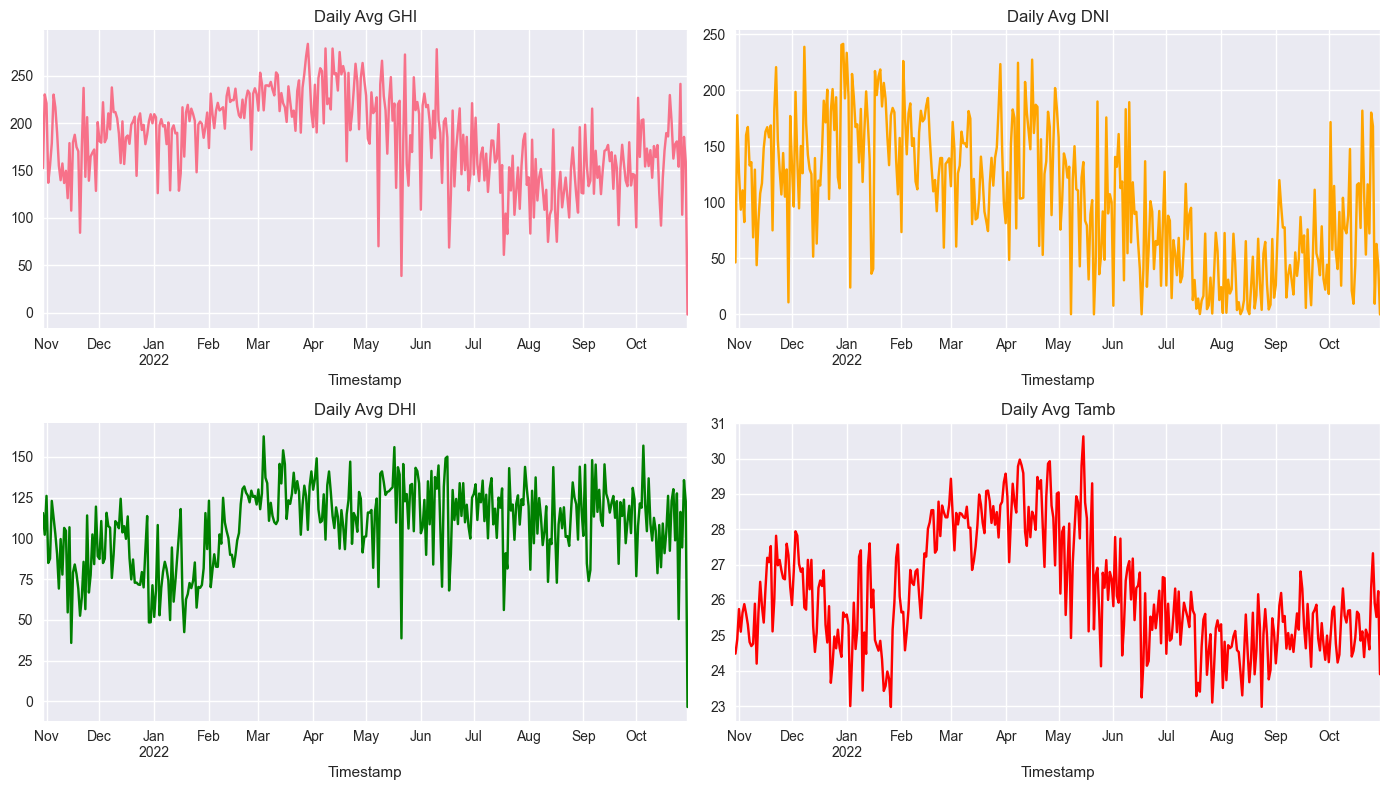

In [26]:
 # Convert 'Timestamp' column to datetime format
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])
# Set Timestamp as index for time-based operations
df_clean.set_index('Timestamp', inplace=True)

# Create 2x2 subplot grid for daily averages
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
# Resample to daily mean and plot GHI
df_clean['GHI'].resample('D').mean().plot(ax=axes[0,0], title='Daily Avg GHI')
df_clean['DNI'].resample('D').mean().plot(ax=axes[0,1], title='Daily Avg DNI', color='orange')
df_clean['DHI'].resample('D').mean().plot(ax=axes[1,0], title='Daily Avg DHI', color='green')
df_clean['Tamb'].resample('D').mean().plot(ax=axes[1,1], title='Daily Avg Tamb', color='red')
plt.tight_layout()                           # Adjust spacing to prevent overlap
plt.show()                                   # Display the plot

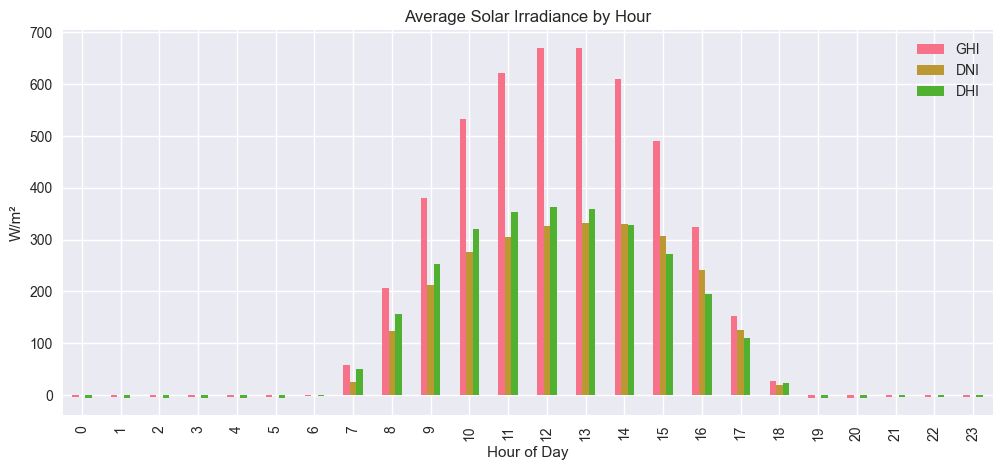

In [27]:
# Analyze hourly patterns across the day
hourly = df_clean.groupby(df_clean.index.hour)[['GHI', 'DNI', 'DHI']].mean()  # Group by hour
# Plot average irradiance by hour of day
hourly.plot(kind='bar', figsize=(12,5), title='Average Solar Irradiance by Hour')
plt.xlabel('Hour of Day')                   
plt.ylabel('W/m²')                         
plt.show()

### 4. Cleaning Impact


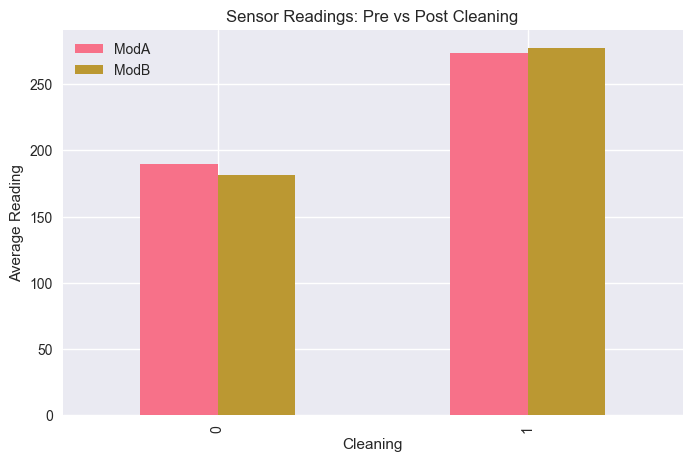

In [28]:
# Group data by 'Cleaning' flag (0 = before, 1 = after)
cleaning_effect = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()
# Bar plot showing sensor improvement after cleaning
cleaning_effect.plot(kind='bar', figsize=(8,5), title='Sensor Readings: Pre vs Post Cleaning')
plt.ylabel('Average Reading')                # Y-axis: sensor output
plt.show()

### 5. Correlation Heatmap

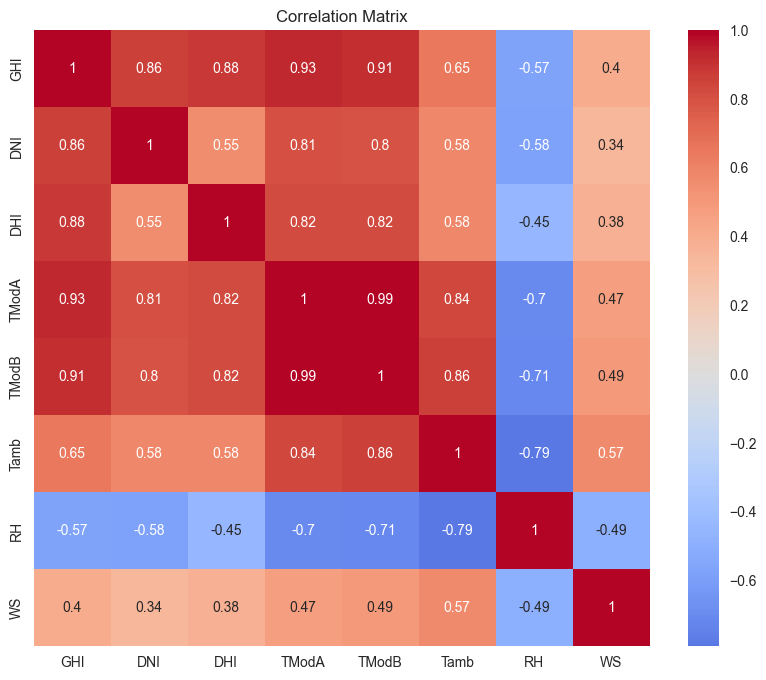

In [29]:
# Select variables for correlation analysis
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB', 'Tamb', 'RH', 'WS']
corr = df_clean[corr_cols].corr()            # Compute Pearson correlation matrix
# Create heatmap with annotations
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix')              
plt.show()

### 7. Wind Rose 

In [30]:
import plotly.express as px
# Create wind speed bins
bins = [0, 2, 4, 6, 8, 10]
labels = ['0-2 m/s', '2-4 m/s', '4-6 m/s', '6-8 m/s', '8-10 m/s']
df_clean['WS_bin'] = pd.cut(df_clean['WS'], bins=bins, labels=labels, include_lowest=True)

# Round wind direction to nearest 10° for cleaner plot
df_clean['WD_rounded'] = (df_clean['WD'] // 10) * 10

# Count frequency
wind_data = df_clean.groupby(['WD_rounded', 'WS_bin']).size().reset_index(name='count')

# Create polar bar chart (wind rose)
fig = px.bar_polar(
    wind_data,
    r='count',
    theta='WD_rounded',
    color='WS_bin',
    template="plotly_dark",
    title='Wind Rose: Wind Speed by Direction (sierraleone-bumbuna)',
    color_discrete_sequence=px.colors.sequential.Plasma_r
)

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True),
        angularaxis=dict(direction="clockwise", period=360)
    ),
    showlegend=True,
    height=600
)

fig.show()

### 8. Histograms

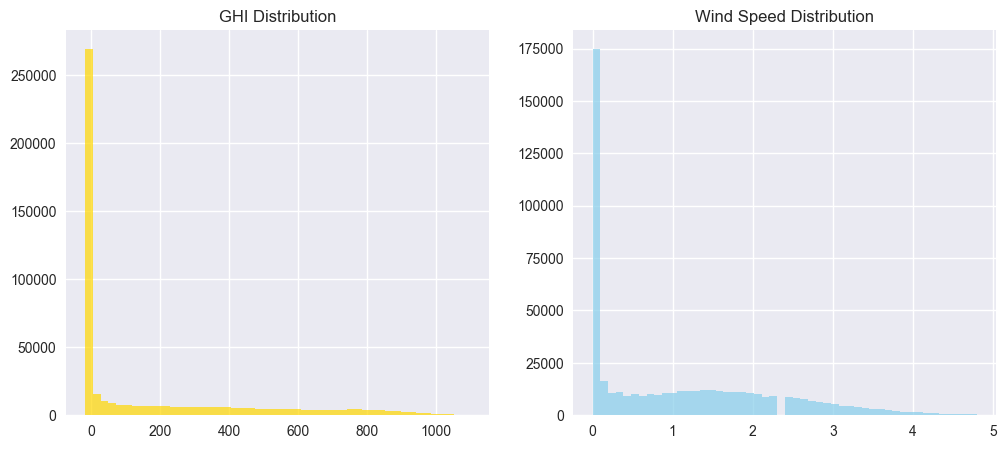

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
# Distribution of GHI
df_clean['GHI'].hist(bins=50, ax=axes[0], alpha=0.7, color='gold')
# Distribution of wind speed
df_clean['WS'].hist(bins=50, ax=axes[1], alpha=0.7, color='skyblue')
axes[0].set_title('GHI Distribution')
axes[1].set_title('Wind Speed Distribution')
plt.show()

### 9. Bubble Chart: GHI vs Tamb (bubble = RH)

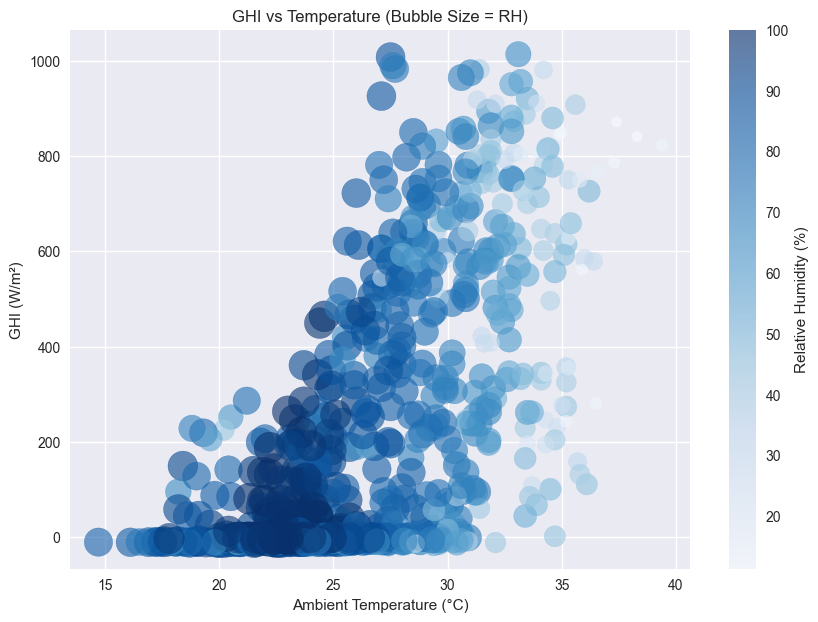

In [32]:
# Sample 1000 points to avoid overplotting
sample = df_clean.sample(1000, random_state=42)
plt.figure(figsize=(10,7))
# Scatter: x=Tamb, y=GHI, size=RH*5, color=RH
scatter = plt.scatter(sample['Tamb'], sample['GHI'], 
                     s=sample['RH']*5, c=sample['RH'], cmap='Blues', alpha=0.6)
plt.colorbar(scatter, label='Relative Humidity (%)')  # Colorbar for RH
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('GHI (W/m²)')
plt.title('GHI vs Temperature (Bubble Size = RH)')
plt.show()

### 10. Export Cleaned Data

In [33]:
# Drop temporary columns before saving
df_clean.drop(columns=['is_outlier', 'WS_bin'], errors='ignore').to_csv('../data/sierraleone-bumbuna_clean.csv', index=True)
print("Exported: data/sierraleone-bumbuna_clean.csv")      # Confirm export (file not committed)

Exported: data/sierraleone-bumbuna_clean.csv
